## Part 3 — Inference

Inference is a forward pass only. It needs no automatic differentiation and no optimiser state, and it accepts inputs of any size.

| | Training (Part 2) | Inference (Part 3) |
|---|---|---|
| Gradients / optimiser | required | not required |
| Input size | 40×40 patches | any size |
| Memory | forward + backward activations | forward activations only; can be tiled |

This notebook:
1. Rebuilds the architecture and loads `denoiser.jld2`
2. Denoises the demo image and compares against classical filters
3. Measures robustness across noise types and levels
4. Demonstrates tiled inference for large images
5. Tests an out-of-distribution noise type

In [1]:
using Pkg; Pkg.activate("."); Pkg.instantiate()

using Flux, Images, FileIO, JLD2, Random, Statistics, Plots

isfile("denoiser.jld2") || error("denoiser.jld2 not found: run 02_denoise_training.ipynb first")

  Activating 

project at `~/ws_julia/Eco-workshop-n8`


true

### 1. Load the model
`Flux.state` stores only the weights. The architecture must be rebuilt identically; if it does not match, `Flux.loadmodel!` raises an error.
The definition is repeated here to keep the notebook self-contained. In a real project it would live in a shared module.

In [2]:
subtract_noise(noise, x) = x .- noise

function build_denoiser(; c=24, depth=7)
    noise_estimator = Chain(
        Conv((3, 3), 3 => c, relu; pad=1),
        [Conv((3, 3), c => c, relu; pad=1) for _ in 1:depth-2]...,
        Conv((3, 3), c => 3; pad=1),
    )
    return SkipConnection(noise_estimator, subtract_noise)
end

saved  = JLD2.load("denoiser.jld2")
config = saved["config"]
model  = build_denoiser(; c = config.c, depth = config.depth)
Flux.loadmodel!(model, saved["model_state"])
Flux.testmode!(model)      # inference mode for Dropout/BatchNorm (a no-op here; good practice)
println("config: ", config)
println("parameters: ", sum(length, Flux.trainables(model)))

config: (

c = 24, depth = 7, patch = 40, σ_train = (0.05, 0.35), p_train = (0.0, 0.2), epochs = 10)
parameters: 

27363


### 2. Helpers
The model has no downsampling layers, so it accepts any height and width. `denoise` adds a batch dimension, runs the model, and clamps the output to [0, 1].

In [3]:
img_to_tensor(img) = permutedims(Float32.(channelview(RGB{Float32}.(img))), (2, 3, 1))
tensor_to_img(x)   = colorview(RGB, permutedims(clamp.(x, 0f0, 1f0), (3, 1, 2)))

# Noise models for single H×W×3 images (same definitions as Part 2)
add_gaussian_noise(x, σ; rng=Random.default_rng()) =
    clamp.(x .+ Float32(σ) .* randn(rng, Float32, size(x)), 0f0, 1f0)

function add_impulse_noise(x, p; rng=Random.default_rng())
    hit = rand(rng, Float32, size(x, 1), size(x, 2), 1) .< p
    return ifelse.(hit, rand(rng, Float32, size(x)), x)
end

add_mixed_noise(x, σ, p; rng=Random.default_rng()) = add_impulse_noise(add_gaussian_noise(x, σ; rng), p; rng)

psnr(x, ref) = 10 * log10(1 / mean(abs2, x .- ref))

denoise(model, x::AbstractArray{Float32,3}) = clamp.(model(reshape(x, size(x)..., 1))[:, :, :, 1], 0f0, 1f0)

side_by_side(xs...) = mosaicview([tensor_to_img(x) for x in xs]; nrow=1, npad=8, fillvalue=RGB{Float32}(1, 1, 1))

side_by_side (generic function with 1 method)

#### 2.1 Classical baselines
- **Gaussian blur:** suppresses Gaussian noise but smears edges.
- **Median filter:** the standard method for impulse noise.

For each input, the filter strength or window size with the best PSNR is used, which makes these strong baselines.

In [4]:
gaussian_blur(x, s) = img_to_tensor(imfilter(tensor_to_img(x), Kernel.gaussian(s)))
median_filter(x, w) = cat([mapwindow(median, x[:, :, ch], (w, w)) for ch in 1:3]...; dims=3)

best_of(f, x, clean, params) = maximum(psnr(f(x, k), clean) for k in params)
best_blur(x, clean)   = best_of(gaussian_blur, x, clean, (0.5, 1.0, 1.5, 2.0))
best_median(x, clean) = best_of(median_filter, x, clean, (3, 5))

best_median (generic function with 1 method)

### 3. Denoise the demo image
The image is used at its native resolution (539×600) with mixed noise: Gaussian σ = 0.15 plus 10 % random-valued impulse noise. The bottom 20 % was never seen during training.

size (

539, 600, 3) │ inference 0.396 s
PSNR noisy          : 14.26

 dB
PSNR best blur      : 21.67

 dB
PSNR best median    : 24.94

 dB
PSNR neural denoiser: 25.67 dB


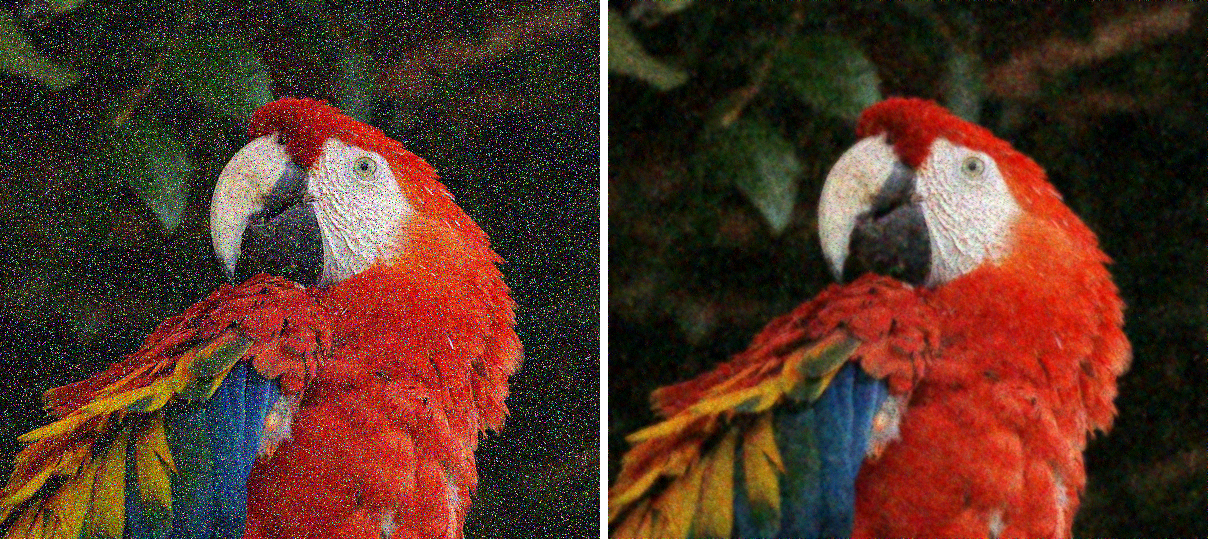

In [5]:
img   = load("image.png")
clean = img_to_tensor(img)
noisy = add_mixed_noise(clean, 0.15, 0.10; rng=Xoshiro(2026))

denoise(model, noisy)                               # warm-up (compilation)
t = @elapsed restored = denoise(model, noisy)

println("size ", size(clean), " │ inference ", round(t; digits=3), " s")
println("PSNR noisy          : ", round(psnr(noisy, clean); digits=2), " dB")
println("PSNR best blur      : ", round(best_blur(noisy, clean); digits=2), " dB")
println("PSNR best median    : ", round(best_median(noisy, clean); digits=2), " dB")
println("PSNR neural denoiser: ", round(psnr(restored, clean); digits=2), " dB")
side_by_side(noisy, restored)                       # noisy │ denoised

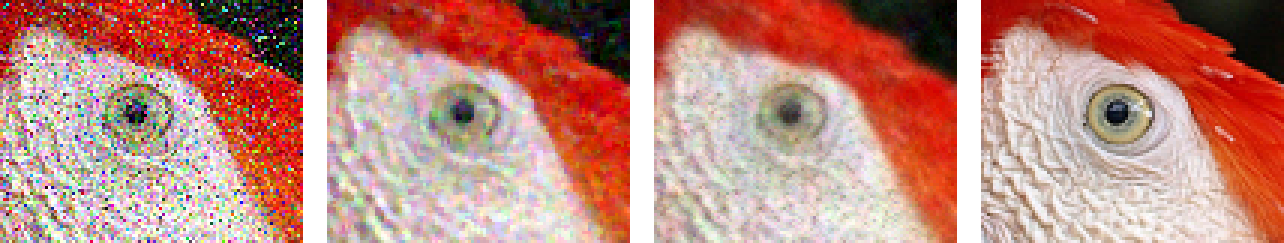

In [6]:
# Detail: noisy │ median 3×3 │ neural denoiser │ clean
rows, cols = 130:210, 320:420
zoom(x) = x[rows, cols, :]
repeat(side_by_side(zoom(noisy), zoom(median_filter(noisy, 3)), zoom(restored), zoom(clean)); inner=(3, 3))

### 4. Robustness across noise types and levels
Training covered Gaussian σ ∈ [0.05, 0.35] and impulse p ∈ [0, 0.20]. Levels above these ranges test extrapolation.

In [7]:
function sweep(make_noisy, levels)
    map(levels) do l
        n = make_noisy(l)
        (level = l, noisy = psnr(n, clean), blur = best_blur(n, clean),
         median = best_median(n, clean), net = psnr(denoise(model, n), clean))
    end
end

σs = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]
ps = [0.05, 0.10, 0.20, 0.30]
res_gauss   = sweep(σ -> add_gaussian_noise(clean, σ; rng=Xoshiro(1)), σs)
res_impulse = sweep(p -> add_impulse_noise(clean, p; rng=Xoshiro(1)), ps)

for (title, res) in (("Gaussian σ", res_gauss), ("Impulse p", res_impulse))
    println(title)
    for r in res
        println("  ", rpad(r.level, 5), "│ noisy ", round(r.noisy; digits=2), " │ blur ", round(r.blur; digits=2),
                " │ median ", round(r.median; digits=2), " │ network ", round(r.net; digits=2), " dB")
    end
end

Gaussian σ


  0.05 │ noisy 26.76 │ blur 30.27 │ median 29.8 │ network 28.76 dB
  0.1  │ noisy 21.31 │ blur 27.84 │ median 27.44 │ network 27.83 dB
  0.2  │ noisy 15.93 │ blur 23.66 │ median 24.63 │ network 25.98 dB
  0.3  │ noisy 12.83 │ blur 20.43 │ median 22.36 │ network 24.36 dB
  0.4  │ noisy 10.76 │ blur 17.92 │ median 20.54 │ network 22.79 dB
  0.5  │ noisy 9.35 │ blur 16.07 │ median 19.04 │ network 21.31 dB
Impulse p
  0.05 │ noisy 19.36 │ blur 26.96 │ median 31.89 │ network 28.03 dB
  0.1  │ noisy 16.29 │ blur 24.44 │ median 31.26 │ network 27.02 dB
  0.2  │ noisy 13.29 │ blur 20.63 │ median 28.8 │ network 25.13 dB
  0.3  │ noisy 11.52 │ blur 17.8 │ median 27.67 │ network 22.83 dB


On Gaussian and mixed noise the network outperforms both filters, and the margin grows with the noise level. On impulse noise alone, the median filter remains stronger: it is designed specifically for isolated outliers, while the network is trained to handle a mixture of noise types.

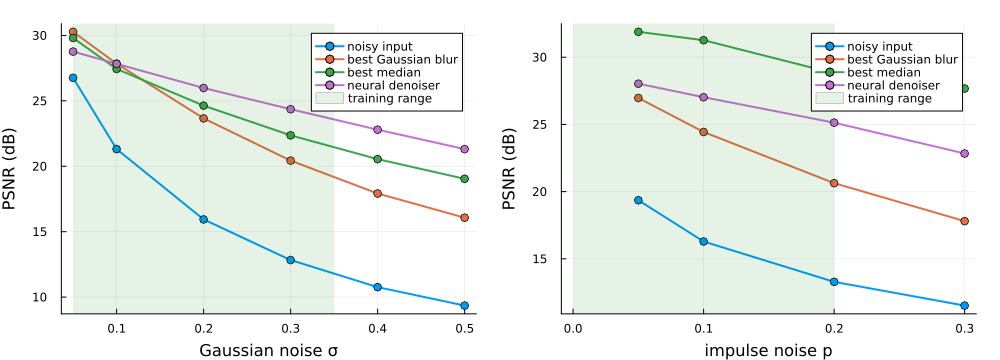

In [8]:
function sweep_plot(res, xlabel, trained)
    lv = getfield.(res, :level)
    p = plot(lv, getfield.(res, :noisy); marker=:o, lw=2, label="noisy input", xlabel, ylabel="PSNR (dB)")
    plot!(p, lv, getfield.(res, :blur);   marker=:o, lw=2, label="best Gaussian blur")
    plot!(p, lv, getfield.(res, :median); marker=:o, lw=2, label="best median")
    plot!(p, lv, getfield.(res, :net);    marker=:o, lw=2, label="neural denoiser")
    vspan!(p, collect(trained); alpha=0.1, color=:green, label="training range")
end
plot(sweep_plot(res_gauss, "Gaussian noise σ", (0.05, 0.35)),
     sweep_plot(res_impulse, "impulse noise p", (0.0, 0.20));
     layout=(1, 2), size=(1000, 360), margin=4Plots.mm, legend=:topright)

### 5. Tiled inference for large images
A single pass over the 539×600 demo image needs about 31 MB per 24-channel activation, which is easily affordable. A 12-megapixel photo (4000×3000) would need about 1.1 GB per activation.
Tiled inference bounds the memory: it processes 256×256 tiles, each with a margin of surrounding context, and writes back only the tile core. The receptive field is 15×15 pixels, so a margin of at least 7 pixels gives exactly the same result as a single pass. Peak memory then depends on the tile size, not the image size.

In [9]:
function denoise_tiled(model, x; tile=256, margin=16)
    H, W = size(x, 1), size(x, 2)
    out = similar(x)
    for i in 1:tile:H, j in 1:tile:W
        ie, je = min(i + tile - 1, H), min(j + tile - 1, W)     # tile core
        a, b = max(i - margin, 1), min(ie + margin, H)          # core + margin
        c, d = max(j - margin, 1), min(je + margin, W)
        y = denoise(model, x[a:b, c:d, :])
        out[i:ie, j:je, :] .= y[(i - a + 1):(ie - a + 1), (j - c + 1):(je - c + 1), :]
    end
    return out
end

t = @elapsed restored_tiled = denoise_tiled(model, noisy)
println("tiles: ", cld(size(noisy, 1), 256) * cld(size(noisy, 2), 256), " │ tiled inference ", round(t; digits=2), " s")
println("max |tiled − single pass| = ", maximum(abs, restored_tiled .- restored))

tiles: 9

 │ tiled inference 0.91 s
max |tiled − single pass| = 0.0

In [10]:
save("noisy.png", tensor_to_img(noisy))
save("denoised.png", tensor_to_img(restored))

### 6. Out-of-distribution noise
Row-stripe noise (a random brightness offset per image row, as produced by some sensors) is spatially correlated. The training noise is independent per pixel, so stripe noise lies outside the training distribution.

input  : 21.63

 dB
neural : 25.39 dB


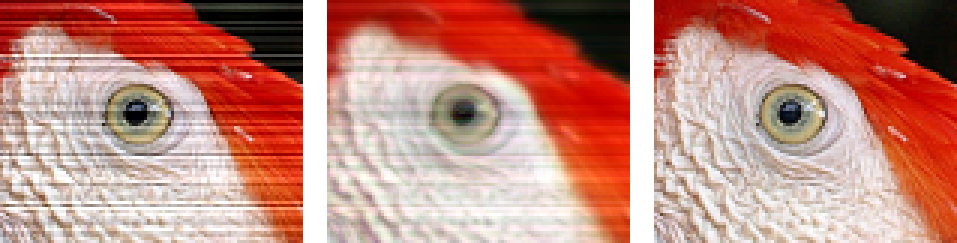

In [11]:
add_stripe_noise(x, s; rng=Random.default_rng()) =
    clamp.(x .+ Float32(s) .* randn(rng, Float32, size(x, 1), 1, 1), 0f0, 1f0)

st_noisy = add_stripe_noise(clean, 0.10; rng=Xoshiro(3))
st_net   = denoise(model, st_noisy)

println("input  : ", round(psnr(st_noisy, clean); digits=2), " dB")
println("neural : ", round(psnr(st_net, clean); digits=2), " dB")
repeat(side_by_side(zoom(st_noisy), zoom(st_net), zoom(clean)); inner=(3, 3))   # input │ network │ clean

PSNR improves, but residual banding remains visible and fine texture is over-smoothed: the network was never shown correlated noise and has no specific mechanism to remove it. A network generalises reliably only within its training distribution. Because the training data is synthesized, the fix is to add `add_stripe_noise` to the noise pipeline in Part 2 and retrain.

### Summary

| Step | Tool |
|---|---|
| Rebuild and load | `build_denoiser`, `JLD2.load`, `Flux.loadmodel!` |
| Inference mode | `Flux.testmode!` |
| Arbitrary input size | fully convolutional network, no downsampling |
| Bounded memory | `denoise_tiled` (tile + margin ≥ receptive-field radius) |
| Evaluation | PSNR against `imfilter` and `mapwindow` baselines |

**Exercises**
1. Set `margin` in `denoise_tiled` below 7 pixels and measure the deviation from the full-image pass.
2. Add stripe noise to the training mixture in Part 2, then rerun Section 6.
3. Compare inference time for `c = 16`, 24 and 32.